## 0. Import thư viện

In [ ]:
import os, sys, warnings, datetime, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from collections import Counter
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
import joblib

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)

SAVE_DIR = os.path.dirname(os.path.abspath('train_model_gold.ipynb'))
if not os.access(SAVE_DIR, os.W_OK):
    SAVE_DIR = os.path.expanduser('~/Desktop/vietnam-monitor/src/ml')
print(f'Save dir: {SAVE_DIR}')
print('Pass')

Save dir: /Users/datvu/Desktop/vietnam-monitor/src/ml
✅ Import thành công


---
## Bước 1 — Cấu hình

In [ ]:
HORIZON   = 5
THRESHOLD = 1.0
MODE      = "BINARY"
GOLD_TICKER = "GC=F"

TECH_FEATURES = [
    "ret_1", "ret_3", "ret_5", "ret_10", "ret_20",
    "ema5_ratio", "ema20_ratio", "ema5_ema20",
    "rsi", "macd_hist", "bb_pos",
    "atr_ratio", "vol_ratio",
    "stoch_k", "williams_r",
    "high20_dist", "low20_dist",
]

MACRO_FEATURES = [
    "usd_ret1",  "usd_ret3",  "usd_ret5",   
    "tnx_ret1",  "tnx_ret3",                
    "oil_ret1",  "oil_ret3",                
    "vix_ret1",  "vix_level",               
    "gs_ratio",                           
]

FEATURES = TECH_FEATURES + MACRO_FEATURES

print(f"Tech features : {len(TECH_FEATURES)}")
print(f"Macro features: {len(MACRO_FEATURES)}")
print(f"Tong          : {len(FEATURES)} features")


Tech features : 17
Macro features: 10
Tong          : 27 features


---
## Bước 2 — Feature Engineering



In [ ]:
def compute_features(df_gold, df_silver=None, df_usd=None, df_tnx=None, df_oil=None, df_vix=None):
    """
    Tinh 28 features = 17 ky thuat + 11 macro (voi lag).
    Cai tien chinh so voi v1:
      - Macro lag: USD/TNX/Oil theo 1, 3, 5 ngay (bat momentum da huong)
      - VIX level: muc tuyet doi VIX (>30=so hai cao, <15=tu man)
      - Gold/Silver ratio: khi ratio tang cao bat thuong -> vang co the dao chieu
    """
    df = df_gold.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.columns = [c.lower() for c in df.columns]
    df = df.sort_index().dropna()

    df["ret_1"]  = df["close"].pct_change(1)  * 100
    df["ret_3"]  = df["close"].pct_change(3)  * 100
    df["ret_5"]  = df["close"].pct_change(5)  * 100
    df["ret_10"] = df["close"].pct_change(10) * 100
    df["ret_20"] = df["close"].pct_change(20) * 100
    df["ema5"]  = df["close"].ewm(span=5,  adjust=False).mean()
    df["ema20"] = df["close"].ewm(span=20, adjust=False).mean()
    df["ema5_ratio"]  = (df["close"] / df["ema5"]  - 1) * 100
    df["ema20_ratio"] = (df["close"] / df["ema20"] - 1) * 100
    df["ema5_ema20"]  = (df["ema5"]  / df["ema20"] - 1) * 100
    delta    = df["close"].diff()
    avg_gain = delta.clip(lower=0).ewm(com=13, adjust=False).mean()
    avg_loss = (-delta.clip(upper=0)).ewm(com=13, adjust=False).mean()
    df["rsi"] = 100 - 100 / (1 + avg_gain / (avg_loss + 1e-9))
    ema12 = df["close"].ewm(span=12, adjust=False).mean()
    ema26 = df["close"].ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    df["macd_hist"] = (macd - macd.ewm(span=9, adjust=False).mean()) / df["close"] * 100
    ma20  = df["close"].rolling(20).mean()
    std20 = df["close"].rolling(20).std()
    df["bb_pos"] = ((df["close"] - (ma20 - 2*std20)) / (4*std20 + 1e-9)).clip(0, 1)
    df["atr_ratio"] = (df["high"] - df["low"]) / df["close"] * 100
    if "volume" in df.columns and df["volume"].sum() > 0:
        df["vol_ratio"] = df["volume"] / (df["volume"].rolling(20).mean() + 1)
    else:
        df["vol_ratio"] = 1.0
    low14  = df["low"].rolling(14).min()
    high14 = df["high"].rolling(14).max()
    df["stoch_k"]    = ((df["close"] - low14) / (high14 - low14 + 1e-9) * 100).clip(0, 100)
    df["williams_r"] = ((high14 - df["close"]) / (high14 - low14 + 1e-9) * -100).clip(-100, 0)
    high20 = df["high"].rolling(20).max()
    low20  = df["low"].rolling(20).min()
    df["high20_dist"] = (df["close"] / high20 - 1) * 100
    df["low20_dist"]  = (df["close"] / low20  - 1) * 100

    def add_macro(col1, col3, col5, df_macro):
        """Them 1/3/5-ngay return cua 1 macro ticker vao df."""
        if df_macro is None: 
            df[col1] = df[col3] = 0.0
            if col5: df[col5] = 0.0
            return
        dm = df_macro.copy()
        if isinstance(dm.columns, pd.MultiIndex):
            dm.columns = dm.columns.get_level_values(0)
        dm.columns = [c.lower() for c in dm.columns]
        c = dm["close"].reindex(df.index, method="ffill")
        df[col1] = c.pct_change(1) * 100
        df[col3] = c.pct_change(3) * 100
        if col5: df[col5] = c.pct_change(5) * 100

    add_macro("usd_ret1", "usd_ret3", "usd_ret5", df_usd)
    add_macro("tnx_ret1", "tnx_ret3", None,       df_tnx)
    add_macro("oil_ret1", "oil_ret3", None,        df_oil)

    if df_vix is not None:
        dv = df_vix.copy()
        if isinstance(dv.columns, pd.MultiIndex):
            dv.columns = dv.columns.get_level_values(0)
        dv.columns = [c.lower() for c in dv.columns]
        vc = dv["close"].reindex(df.index, method="ffill")
        df["vix_ret1"]  = vc.pct_change(1) * 100
        df["vix_level"] = vc / 100   
    else:
        df["vix_ret1"] = df["vix_level"] = 0.0

    if df_silver is not None:
        ds = df_silver.copy()
        if isinstance(ds.columns, pd.MultiIndex):
            ds.columns = ds.columns.get_level_values(0)
        ds.columns = [c.lower() for c in ds.columns]
        sc = ds["close"].reindex(df.index, method="ffill")
        gs_raw = df["close"] / (sc + 1e-9)        
        gs_ma  = gs_raw.rolling(60).mean()         
        df["gs_ratio"] = (gs_raw / gs_ma - 1) * 100  
    else:
        df["gs_ratio"] = 0.0

    return df

print("compute_features v2: 17 ky thuat + 11 macro = 28 features")


compute_features v2: 17 ky thuat + 11 macro = 28 features


In [ ]:
print("Tai du lieu 10 nam tu Yahoo Finance...")

def fetch_ticker(ticker, period="10y"):
    try:
        df = yf.download(ticker, period=period, interval="1d", progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df.columns = [c.lower() for c in df.columns]
        return df.dropna()
    except Exception as e:
        print(f"  WARN {ticker}: {e}")
        return None

df_gold   = fetch_ticker("GC=F",     "10y")   
df_silver = fetch_ticker("SI=F",     "10y")   
df_usd    = fetch_ticker("DX-Y.NYB", "10y")  
df_tnx    = fetch_ticker("^TNX",     "10y")   
df_oil    = fetch_ticker("CL=F",     "10y")   
df_vix    = fetch_ticker("^VIX",     "10y")   

for name, dfm in [("Gold",df_gold),("Silver",df_silver),("USD",df_usd),
                  ("TNX",df_tnx),("Oil",df_oil),("VIX",df_vix)]:
    if dfm is not None:
        n = len(dfm)
        print(f"  {name:8s}: {n:,} phien | {dfm.index[0].date()} - {dfm.index[-1].date()}")
    else:
        print(f"  {name:8s}: KHONG CO DU LIEU")

gold_price = df_gold["close"].iloc[-1]
print(f"\nGia vang gan nhat: ${gold_price:,.1f}/oz")


Tai du lieu 10 nam tu Yahoo Finance...
  Gold    : 2,514 phien | 2016-03-21 - 2026-03-20
  Silver  : 2,514 phien | 2016-03-21 - 2026-03-20
  USD     : 2,514 phien | 2016-03-21 - 2026-03-20
  TNX     : 2,513 phien | 2016-03-21 - 2026-03-19
  Oil     : 2,515 phien | 2016-03-21 - 2026-03-20
  VIX     : 2,513 phien | 2016-03-21 - 2026-03-18

Gia vang gan nhat: $4,667.1/oz


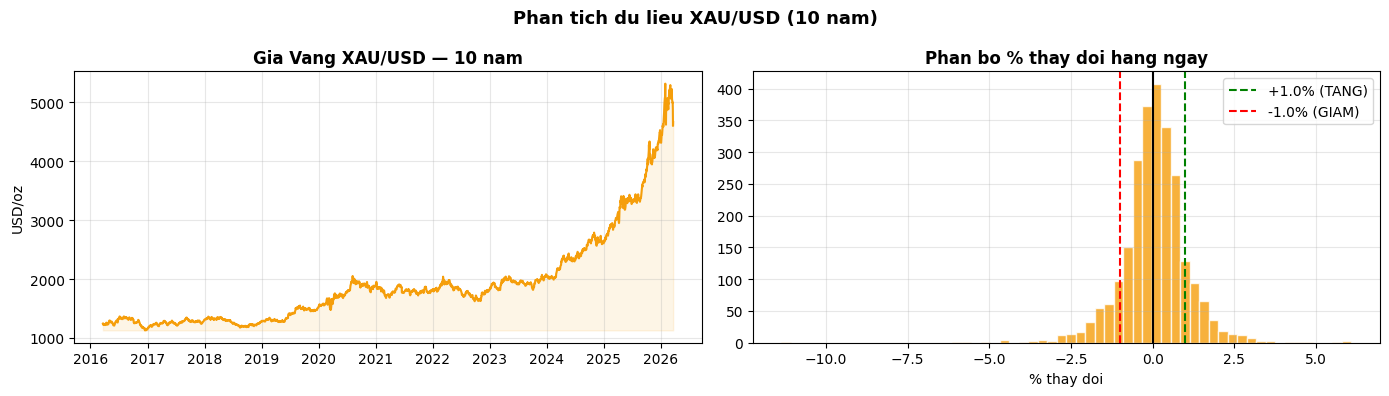

Volatility hang ngay TB: 1.02%
Max tang 1 ngay: +6.08%
Max giam 1 ngay: -11.37%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_gold.index, df_gold["close"], color="#f59e0b", lw=1.5)
axes[0].fill_between(df_gold.index, df_gold["close"].min(), df_gold["close"],
                      alpha=0.1, color="#f59e0b")
axes[0].set_title("Gia Vang XAU/USD — 10 nam", fontweight="bold")
axes[0].set_ylabel("USD/oz")
axes[0].grid(alpha=0.3)

daily_ret = df_gold["close"].pct_change().dropna() * 100
axes[1].hist(daily_ret, bins=60, color="#f59e0b", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="black", lw=1.5)
axes[1].axvline(THRESHOLD,  color="green", ls="--", lw=1.5, label=f"+{THRESHOLD}% (TANG)")
axes[1].axvline(-THRESHOLD, color="red",   ls="--", lw=1.5, label=f"-{THRESHOLD}% (GIAM)")
axes[1].set_title("Phan bo % thay doi hang ngay", fontweight="bold")
axes[1].set_xlabel("% thay doi")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Phan tich du lieu XAU/USD (10 nam)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

std_val = daily_ret.std()
max_val = daily_ret.max()
min_val = daily_ret.min()
print(f"Volatility hang ngay TB: {std_val:.2f}%")
print(f"Max tang 1 ngay: +{max_val:.2f}%")
print(f"Max giam 1 ngay: {min_val:.2f}%")


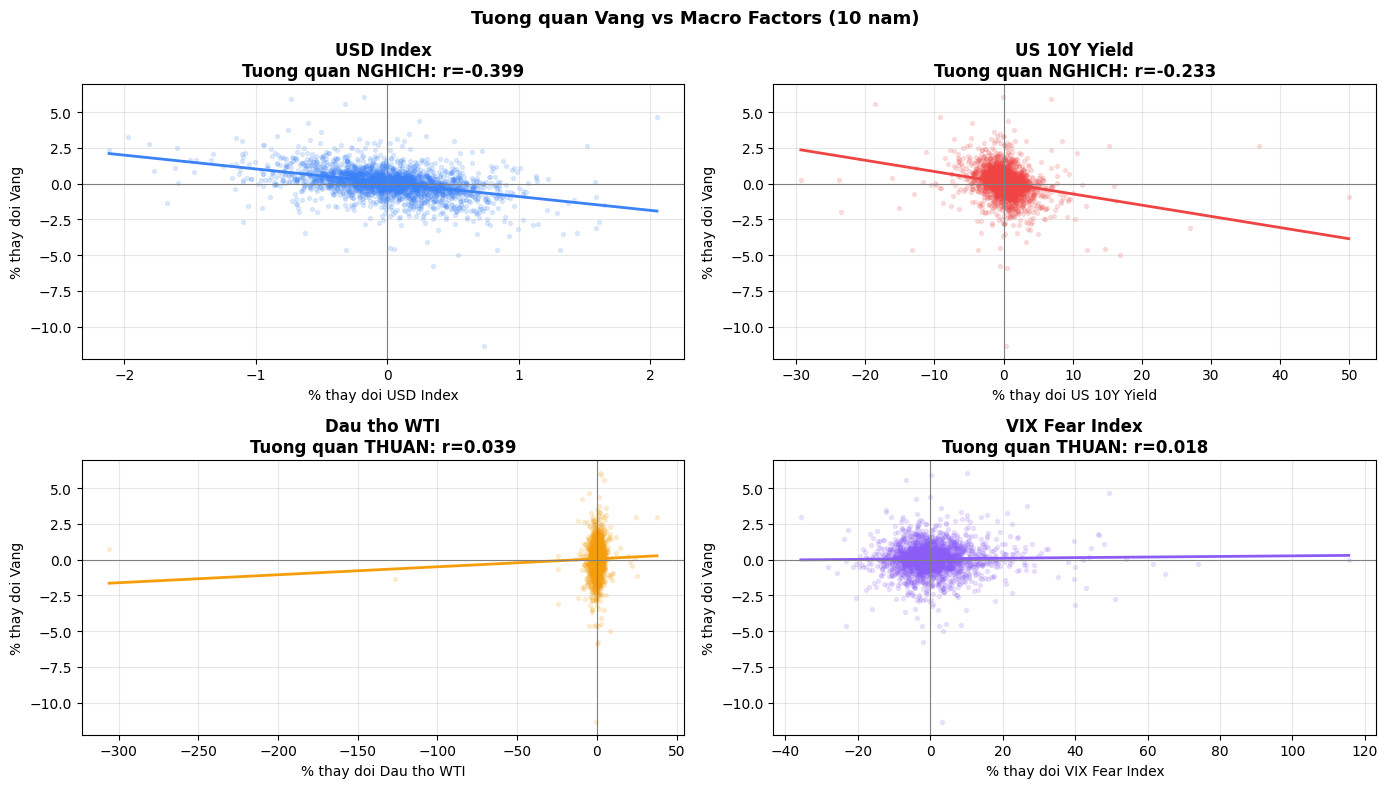

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

macro_pairs = [
    (df_usd,  "USD Index",         "#3b82f6", "NGHICH"),
    (df_tnx,  "US 10Y Yield",      "#ef4444", "NGHICH"),
    (df_oil,  "Dau tho WTI",       "#f59e0b", "THUAN"),
    (df_vix,  "VIX Fear Index",    "#8b5cf6", "THUAN"),
]

for ax, (df_m, name, color, corr_type) in zip(axes, macro_pairs):
    if df_m is None:
        ax.text(0.5, 0.5, f"Khong co du lieu\n{name}", ha="center", va="center")
        continue
    # Align theo ngay
    gold_ret = df_gold["close"].pct_change().dropna()
    macro_ret = df_m["close"].pct_change().dropna()
    combined = pd.concat([gold_ret, macro_ret], axis=1, join="inner").dropna()
    combined.columns = ["gold", "macro"]
    r = combined.corr().iloc[0,1]
    ax.scatter(combined["macro"]*100, combined["gold"]*100,
               alpha=0.15, s=8, color=color)
    # Regression line
    z = np.polyfit(combined["macro"], combined["gold"], 1)
    p = np.poly1d(z)
    xs = np.linspace(combined["macro"].min(), combined["macro"].max(), 100)
    ax.plot(xs*100, p(xs)*100, color=color, lw=2)
    ax.set_title(f"{name}\nTuong quan {corr_type}: r={r:.3f}", fontweight="bold")
    ax.set_xlabel(f"% thay doi {name}")
    ax.set_ylabel("% thay doi Vang")
    ax.grid(alpha=0.3)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)

plt.suptitle("Tuong quan Vang vs Macro Factors (10 nam)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Bước 4 — Tính Features và Tạo Nhãn

Dataset: 2,445 mau
  GIAM      :  606 (24.8%)
  DI NGANG  :  992 (40.6%)
  TANG      :  847 (34.6%)


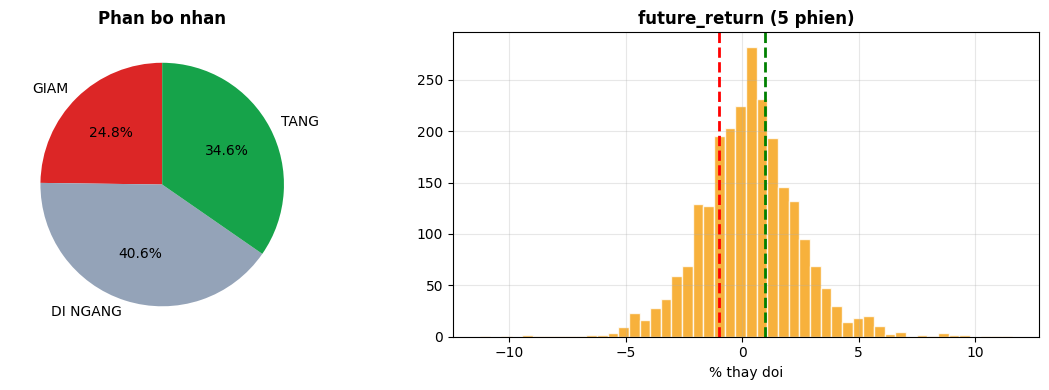

In [ ]:
df_feat = compute_features(df_gold, df_silver, df_usd, df_tnx, df_oil, df_vix)

df_feat["future_return"] = df_feat["close"].pct_change(HORIZON).shift(-HORIZON) * 100
df_feat["label"] = 0
df_feat.loc[df_feat["future_return"] >  THRESHOLD, "label"] =  1
df_feat.loc[df_feat["future_return"] < -THRESHOLD, "label"] = -1

needed   = FEATURES + ["label", "future_return"]
df_clean = df_feat[needed].dropna().iloc[:-HORIZON]

lbl = df_clean["label"].value_counts().sort_index()
print(f"Dataset: {len(df_clean):,} mau")
for k, name in [(-1,"GIAM"), (0,"DI NGANG"), (1,"TANG")]:
    n = lbl.get(k, 0)
    print(f"  {name:10s}: {n:4d} ({n/len(df_clean)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lbl_dict = {k: lbl.get(k,0) for k in [-1,0,1]}
axes[0].pie([lbl_dict[-1], lbl_dict[0], lbl_dict[1]],
            labels=["GIAM","DI NGANG","TANG"],
            colors=["#dc2626","#94a3b8","#16a34a"],
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Phan bo nhan", fontweight="bold")
axes[1].hist(df_clean["future_return"], bins=50, color="#f59e0b", edgecolor="white", alpha=0.8)
axes[1].axvline(THRESHOLD,  color="green", ls="--", lw=2)
axes[1].axvline(-THRESHOLD, color="red",   ls="--", lw=2)
axes[1].set_title(f"future_return ({HORIZON} phien)", fontweight="bold")
axes[1].set_xlabel("% thay doi")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## Bước 5 — Chuẩn bị Dataset và Chia Train/Test

In [ ]:
if MODE == 'BINARY':
    n_flat  = (df_clean['label'] == 0).sum()
    df_clean = df_clean[df_clean['label'] != 0].copy()
    print(f'BINARY mode: bỏ {n_flat} mẫu ĐI NGANG')

X     = df_clean[FEATURES].values
y_cls = df_clean['label'].values
y_ret = df_clean['future_return'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)


split = int(len(X_scaled) * 0.8)
X_tr, X_te   = X_scaled[:split], X_scaled[split:]
yc_tr, yc_te = y_cls[:split],    y_cls[split:]
yr_tr        = y_ret[:split]

print(f'Dataset: {len(df_clean):,} mẫu (mode={MODE})')
print(f'  Train : {len(X_tr):,} mẫu (80%)')
print(f'  Test  : {len(X_te):,} mẫu (20%)')
print(f'Nhãn train: {dict(Counter(yc_tr.tolist()))}')
print(f'Nhãn test : {dict(Counter(yc_te.tolist()))}')

BINARY mode: bỏ 992 mẫu ĐI NGANG
Dataset: 1,453 mẫu (mode=BINARY)
  Train : 1,162 mẫu (80%)
  Test  : 291 mẫu (20%)
Nhãn train: {-1: 524, 1: 638}
Nhãn test : {1: 209, -1: 82}


---
## Bước 6 — Huấn luyện Model

In [ ]:
print("Training Gradient Boosting Classifier...")
clf = GradientBoostingClassifier(
    n_estimators=500,      
    learning_rate=0.03,    
    max_depth=3,           
    min_samples_leaf=8,
    subsample=0.7,         
    max_features="sqrt",
    random_state=42,
)
clf.fit(X_tr, yc_tr)
acc = accuracy_score(yc_te, clf.predict(X_te))
print(f" Gradient Boosting: {acc:.2%}  (baseline 50%, cải thiện +{acc*100-50:.1f}%)")

rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=8,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_tr, yc_tr)
rf_acc = accuracy_score(yc_te, rf.predict(X_te))
print(f"   Random Forest     : {rf_acc:.2%}")
print(f"   Gradient Boosting : {acc:.2%}")

best_name = "Gradient Boosting" if acc >= rf_acc else "Random Forest"
if acc < rf_acc:
    clf = rf; acc = rf_acc
print(f"   -> Dung: {best_name} ({acc:.2%})")

print("\nTraining Regressor...")
reg = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.03,
    max_depth=3, min_samples_leaf=8,
    subsample=0.7, random_state=42,
)
reg.fit(X_tr, yr_tr)
print("Regressor xong")


Training Gradient Boosting Classifier...
✅ Gradient Boosting: 60.14%  (baseline 50%, cải thiện +10.1%)
   Random Forest     : 55.33%
   Gradient Boosting : 60.14%
   -> Dung: Gradient Boosting (60.14%)

Training Regressor...
✅ Regressor xong


---
## Bước 7 — Đánh giá Model

=== Kết quả Test Set (291 mẫu) ===
Accuracy: 60.14%  (baseline: 50%)

              precision    recall  f1-score   support

        GIẢM       0.36      0.52      0.43        82
        TĂNG       0.77      0.63      0.69       209

    accuracy                           0.60       291
   macro avg       0.57      0.58      0.56       291
weighted avg       0.66      0.60      0.62       291



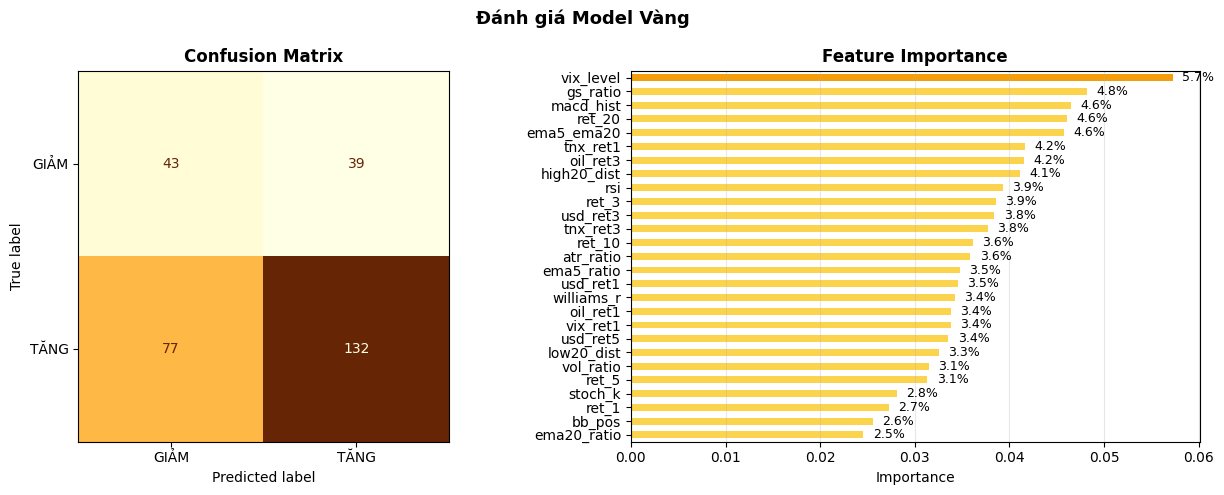


Top 5 features quan trọng nhất:
  vix_level         5.7%  ███████████
  gs_ratio          4.8%  █████████
  macd_hist         4.6%  █████████
  ret_20            4.6%  █████████
  ema5_ema20        4.6%  █████████


In [32]:
y_pred = clf.predict(X_te)

if MODE == 'BINARY':
    target_names = ['GIẢM', 'TĂNG']
    cm_labels    = [-1, 1]
else:
    target_names = ['GIẢM', 'ĐI NGANG', 'TĂNG']
    cm_labels    = [-1, 0, 1]

print(f'=== Kết quả Test Set ({len(X_te):,} mẫu) ===')
print(f'Accuracy: {acc:.2%}  (baseline: 50%)')
print()
print(classification_report(yc_te, y_pred, target_names=target_names, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm_mat = confusion_matrix(yc_te, y_pred, labels=cm_labels)
ConfusionMatrixDisplay(cm_mat, display_labels=target_names).plot(
    ax=axes[0], colorbar=False, cmap='YlOrBr')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Feature Importance
feat_imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors_fi = ['#f59e0b' if v == feat_imp.max() else '#fcd34d' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=axes[1], color=colors_fi)
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].grid(alpha=0.3, axis='x')
for i, v in enumerate(feat_imp.values):
    axes[1].text(v + 0.001, i, f'{v*100:.1f}%', va='center', fontsize=9)

plt.suptitle('Đánh giá Model Vàng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 features quan trọng nhất:')
for fname, fimp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f'  {fname:15s} {fimp*100:5.1f}%  {chr(9608)*int(fimp*200)}')

=== Accuracy theo Confidence ===
------------------------------------------------
  >= 50%     291     60.1%   +10.1%  ██████████
  >= 55%     225     63.1%   +13.1%  █████████████
  >= 60%     154     65.6%   +15.6%  ███████████████
  >= 65%     111     65.8%   +15.8%  ███████████████
  >= 70%      69     69.6%   +19.6%  ███████████████████
  >= 75%      36     66.7%   +16.7%  ████████████████

Confidence >= 60%: 154 mau — Accuracy: 65.6%


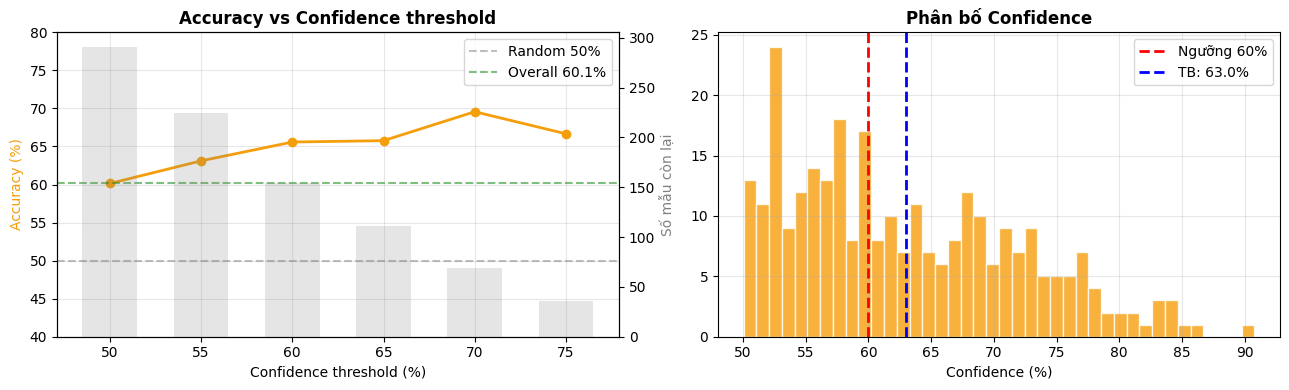

In [ ]:
proba     = clf.predict_proba(X_te)
max_proba = proba.max(axis=1)

print('=== Accuracy theo Confidence ===')
print('-' * 48)
thresholds, accs, ns = [], [], []
for t in np.arange(0.50, 0.80, 0.05):
    mask = max_proba >= t
    if mask.sum() >= 20:
        a = accuracy_score(yc_te[mask], clf.predict(X_te)[mask])
        n = int(mask.sum())
        thresholds.append(t); accs.append(a); ns.append(n)
        bar = chr(9608) * int((a*100 - 50))
        print(f'  >= {t*100:.0f}%   {n:>5,}   {a*100:>6.1f}%   +{a*100-50:>4.1f}%  {bar}')

mask60   = max_proba >= 0.6
n60      = int(mask60.sum())
acc60    = accuracy_score(yc_te[mask60], clf.predict(X_te)[mask60]) if n60 > 0 else 0
print(f'\nConfidence >= 60%: {n60} mau — Accuracy: {acc60:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax2 = axes[0].twinx()
axes[0].plot(np.array(thresholds)*100, np.array(accs)*100, 'o-', color='#f59e0b', lw=2)
axes[0].axhline(50, color='gray', ls='--', alpha=0.5, label='Random 50%')
axes[0].axhline(acc*100, color='green', ls='--', alpha=0.5, label=f'Overall {acc:.1%}')
axes[0].set_ylim(40, 80); axes[0].set_xlabel('Confidence threshold (%)')
axes[0].set_ylabel('Accuracy (%)', color='#f59e0b'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Accuracy vs Confidence threshold', fontweight='bold')
ax2.bar(np.array(thresholds)*100, ns, width=3, alpha=0.2, color='gray')
ax2.set_ylabel('Số mẫu còn lại', color='gray')

axes[1].hist(max_proba*100, bins=40, color='#f59e0b', edgecolor='white', alpha=0.8)
axes[1].axvline(60, color='red', lw=2, ls='--', label='Ngưỡng 60%')
axes[1].axvline(max_proba.mean()*100, color='blue', lw=2, ls='--',
                label=f'TB: {max_proba.mean()*100:.1f}%')
axes[1].set_xlabel('Confidence (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Phân bố Confidence', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Bước 8 — Lưu Model 

In [ ]:
clf_path    = os.path.join(SAVE_DIR, 'model_gold_clf.pkl')
reg_path    = os.path.join(SAVE_DIR, 'model_gold_reg.pkl')
scaler_path = os.path.join(SAVE_DIR, 'scaler_gold.pkl')
meta_path   = os.path.join(SAVE_DIR, 'metadata_gold.json')

joblib.dump(clf,    clf_path)
joblib.dump(reg,    reg_path)
joblib.dump(scaler, scaler_path)

feat_imp_dict = {f: round(float(v), 4) for f, v in zip(FEATURES, clf.feature_importances_)}
metadata = {
    'trained_at':          datetime.datetime.now().isoformat(),
    'ticker':              GOLD_TICKER,
    'n_samples':           int(len(df_clean)),
    'accuracy':            round(float(acc), 4),
    'horizon':             HORIZON,
    'threshold':           THRESHOLD,
    'mode':                MODE,
    'features':            FEATURES,
    'feature_importances': feat_imp_dict,
}
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'Luu vao: {SAVE_DIR}')
print(f'  model_gold_clf.pkl : {os.path.getsize(clf_path)//1024:,} KB')
print(f'  model_gold_reg.pkl : {os.path.getsize(reg_path)//1024:,} KB')
print(f'  scaler_gold.pkl    : {os.path.getsize(scaler_path)} bytes')
print(f'  metadata_gold.json : OK')
print(f'\n  Accuracy  : {acc:.2%}')
print(f'  Horizon   : {HORIZON} phien')
print(f'  So mau    : {len(df_clean):,}')
print(f'  Ngay train: {datetime.date.today()}')


Luu vao: /Users/datvu/Desktop/vietnam-monitor/src/ml
  model_gold_clf.pkl : 593 KB
  model_gold_reg.pkl : 332 KB
  scaler_gold.pkl    : 1247 bytes
  metadata_gold.json : OK

  Accuracy  : 60.14%
  Horizon   : 5 phien
  So mau    : 1,453
  Ngay train: 2026-03-20

-> Restart Flask server de load model moi


---
## Bước 9 — Test thử dự đoán 

In [ ]:
df_today_gold   = yf.download("GC=F",     period="90d", interval="1d", progress=False)
df_today_silver = yf.download("SI=F",     period="90d", interval="1d", progress=False)
df_today_usd    = yf.download("DX-Y.NYB", period="90d", interval="1d", progress=False)
df_today_tnx    = yf.download("^TNX",     period="90d", interval="1d", progress=False)
df_today_oil    = yf.download("CL=F",     period="90d", interval="1d", progress=False)
df_today_vix    = yf.download("^VIX",     period="90d", interval="1d", progress=False)

df_feat_today = compute_features(df_today_gold, df_today_silver, df_today_usd,
                                  df_today_tnx, df_today_oil, df_today_vix)
row   = df_feat_today[FEATURES].dropna().iloc[[-1]]
X_now = scaler.transform(row.values)

pred_cls   = int(clf.predict(X_now)[0])
pred_proba = clf.predict_proba(X_now)[0]
pred_ret   = float(reg.predict(X_now)[0])
classes    = clf.classes_.tolist()
confidence = pred_proba[classes.index(pred_cls)] * 100

dir_map = {1: "TANG", -1: "GIAM", 0: "DI NGANG"}
gold_price_now = float(df_today_gold["close"].iloc[-1].item() if hasattr(df_today_gold["close"].iloc[-1], "item") else df_today_gold["close"].iloc[-1])
print(f"=== Du doan Vang ({datetime.date.today()}) ===")
print(f"Gia vang hom nay : ${gold_price_now:,.1f}/oz")
print(f"Du doan          : {dir_map[pred_cls]}")
print(f"Bien dong KV     : {pred_ret:+.2f}% trong {HORIZON} phien")
print(f"Confidence       : {confidence:.1f}%")
print()
print("Macro signals hom nay:")
for col, name in [("usd_ret1","USD 1d"), ("usd_ret3","USD 3d"), ("usd_ret5","USD 5d"),
                   ("tnx_ret1","TNX 1d"), ("oil_ret1","Oil 1d"),
                   ("vix_ret1","VIX 1d"), ("vix_level","VIX level"),
                   ("gs_ratio","Gold/Silver ratio vs MA60")]:
    if col in row.columns:
        val = float(row[col].iloc[0])
        print(f"  {name:25s}: {val:+.3f}")
print(f"\n-> {'Du tin tuong' if confidence >= 60 else 'Khong du tin tuong (<60%)'}")


KeyError: 'close'